# Chip Dynamics — Fluorescence Detection

Run the trained **pillar** U-Net on a brightfield frame to detect the pillar grid and
band geometry.  Detect cells / organisms using **channel 1 fluorescence** (mCherry)
with mean-subtraction + Gaussian background removal + Otsu thresholding — no ML
required for the cell channel.  Finally builds a `df_cells` table with each object's
position relative to the chip band centre.

In [1]:
# ── Standard + chipanalysis imports ──────────────────────────────────────────
from chipanalysis.utils.file_reader import get_frame, get_pixel_sizes_um, get_timestamps_by_T
from chipanalysis.utils.maye_video_axio import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage import exposure
from skimage.filters import gaussian, threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes
from skimage.measure import label as sk_label, regionprops as sk_regionprops
from skimage.transform import resize as sk_resize

import torch
import torch.nn as nn
import torch.nn.functional as F

%load_ext autoreload
%autoreload 2
%matplotlib widget

## Parameters — edit these before running

In [64]:
# ── CZI file ─────────────────────────────────────────────────────────────────
CZI_PATH   = "/Users/bisot/Documents/PostDoc2/test_data/ICP/ICP16-03.czi"  # ← change this
SCENE      = 3   # scene index (use None for non-scene files)

# ── Frame selection ───────────────────────────────────────────────────────────
TIMEPOINT    = 110    # T index used for pillar detection (fixed reference)
CHANNEL_FLUO = 1    # fluorescence channel (mCherry)
CHANNEL_BF   = 2    # brightfield channel for pillar detection

# ── Fluorescence detection parameters ────────────────────────────────────────
BG_SIGMA_UM   = 1000.0   # Gaussian σ for spatial background estimate (µm)
MIN_OBJ_UM2   = 25.0    # minimum object area (µm²)
MAX_HOLE_UM2  = 5.0     # maximum hole to fill (µm²)
THRESH_FACTOR = 0.2     # fraction of Otsu threshold

# ── Saved pillar model path ───────────────────────────────────────────────────
PILLAR_MODEL_PATH = "/Users/bisot/Documents/PostDoc2/training_data_pillars/unet_pillar_newchip.pth"

# ── Pillar ML inference parameters ───────────────────────────────────────────
PATCH_SIZE_PX    = 256
PATCH_STRIDE_PX  = 128
THRESHOLD_PILLAR = 0.5

## Load CZI file and extract frames

.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value
File        : ICP16-03.czi
Dimensions  : {'S': 8, 'T': 386, 'C': 3, 'M': 4, 'Y': 896, 'X': 896}
Pixel size  : 2.7438 µm/px
  scene 0: 3316×896 px  at (24083, 11742)
  scene 1: 3315×896 px  at (24073, 14245)
  scene 2: 3315×896 px  at (24096, 16757)
  scene 3: 3315×896 px  at (24120, 19283)
  scene 4: 3315×896 px  at (35367, 12483)
  scene 5: 3315×896 px  at (35375, 15029)
  scene 6: 3315×896 px  at (35398, 17513)
  scene 7: 3315×896 px  at (35444, 20064)

BF channel   : ch2  →  (896, 3315)
Fluo channel : ch1  →  (896, 3315)


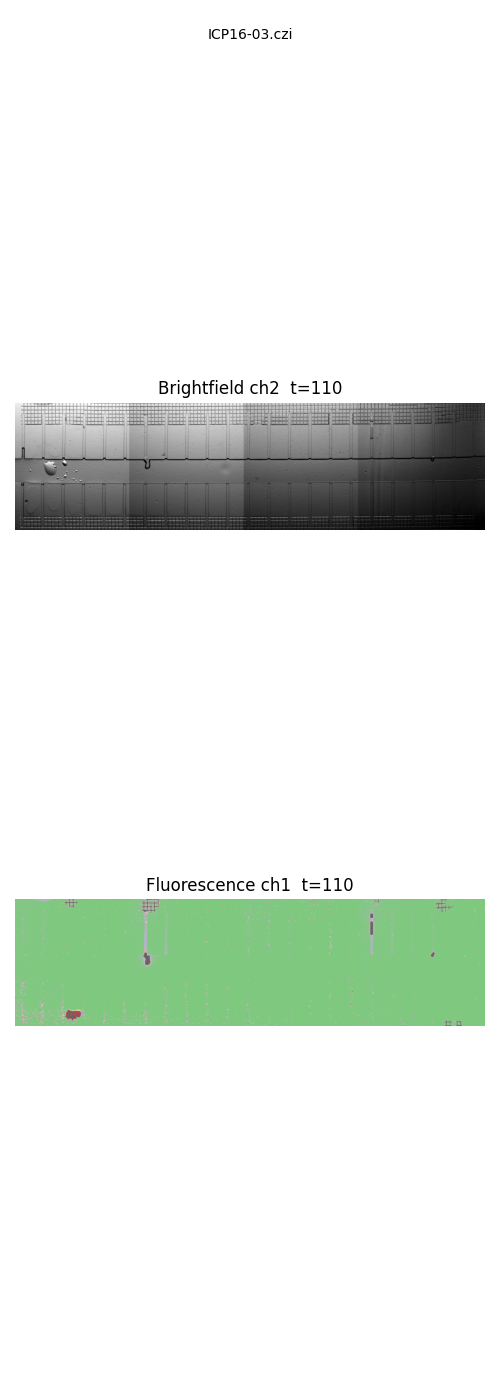

In [65]:
czi_path   = Path(CZI_PATH)
czi        = CziFile(czi_path)

dims       = czi.dims
sizes      = czi.size
dim_sizes  = dict(zip(dims, sizes))
pixel_size = get_pixel_sizes_um(czi)
px_um      = pixel_size["X"]
times      = get_timestamps_by_T(czi, C=0, Z=0)

print(f"File        : {czi_path.name}")
print(f"Dimensions  : {dim_sizes}")
print(f"Pixel size  : {px_um:.4f} µm/px")
if "S" in dim_sizes:
    bboxes = czi.get_all_scene_bounding_boxes()
    for s, bb in bboxes.items():
        print(f"  scene {s}: {bb.w}×{bb.h} px  at ({bb.x}, {bb.y})")

# ── Extract brightfield frame for pillar detection ────────────────────────────
img_bf, img_bf_disp = get_frame(
    czi, TIMEPOINT, CHANNEL_BF, scene=SCENE,
    gamma=1.0, stretch_min=1, stretch_max=99.5,
)
# ── Extract fluorescence frame for cell detection ─────────────────────────────
img_fluo, img_fluo_disp = get_frame(
    czi, TIMEPOINT, CHANNEL_FLUO, scene=SCENE,
    gamma=1.0, stretch_min=1, stretch_max=99.5,
)

print(f"\nBF channel   : ch{CHANNEL_BF}  →  {img_bf.shape}")
print(f"Fluo channel : ch{CHANNEL_FLUO}  →  {img_fluo.shape}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 14))
ax1.imshow(img_bf_disp, cmap="gray")
ax1.set_title(f"Brightfield ch{CHANNEL_BF}  t={TIMEPOINT}")
ax1.axis("off")
ax2.imshow(img_fluo_disp, cmap="Accent")
ax2.set_title(f"Fluorescence ch{CHANNEL_FLUO}  t={TIMEPOINT}")
ax2.axis("off")
plt.suptitle(czi_path.name, fontsize=10)
plt.tight_layout()
plt.show()

In [66]:
from chipanalysis.chip_alignment import align_chip_to_image,get_roi_from_result, ChipGeometry

result = align_chip_to_image(img_bf, pixel_size_um=pixel_size["X"], debug=False, geom=ChipGeometry())
img_bf = result['rotate_fn'](img_bf)
img_fluo = result['rotate_fn'](img_fluo)
img_bf_disp = result['rotate_fn'](img_bf_disp)
img_fluo_disp = result['rotate_fn'](img_fluo_disp)


Temporal mean computed over 10 frames  (ch1  scene=3)
  raw range: [0.0, 2347.9]


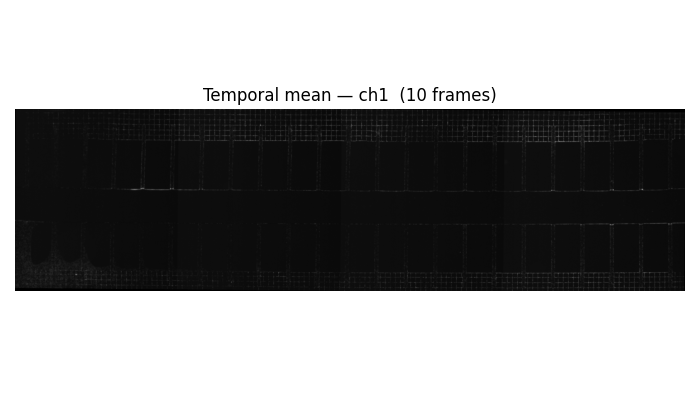

In [67]:
# ── Compute temporal mean image for the fluorescence channel ──────────────────
# Pixel-wise average across all timepoints — captures static background
# (autofluorescence, uneven illumination, chip structure) that persists over time.
# Subtracting it from each frame leaves only what *changes* between frames.

n_times = 10
_accum = None
for t in range(n_times):
    raw, _ = get_frame(czi, t, CHANNEL_FLUO, scene=SCENE)
    frame_f = raw.astype(np.float64)
    frame_f = result['rotate_fn'](frame_f)
    _accum = frame_f if _accum is None else _accum + frame_f

temporal_mean_fluo = (_accum / n_times).astype(np.float32)

# Normalise for display
tmin, tmax = float(temporal_mean_fluo.min()), float(temporal_mean_fluo.max())
temporal_mean_norm = (temporal_mean_fluo - tmin) / (tmax - tmin + 1e-8)

print(f"Temporal mean computed over {n_times} frames  (ch{CHANNEL_FLUO}  scene={SCENE})")
print(f"  raw range: [{tmin:.1f}, {tmax:.1f}]")

fig, ax = plt.subplots(figsize=(7, 4))
ax.imshow(temporal_mean_norm, cmap="gray", vmin=0, vmax=1)
ax.set_title(f"Temporal mean — ch{CHANNEL_FLUO}  ({n_times} frames)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Fluorescence-based cell detection (mCherry / ch1)

**Step 1** subtracts the temporal mean (pixel-wise average over all T) — removes any static
background that is constant across time (autofluorescence, chip structure, uneven illumination).
**Step 2** subtracts a Gaussian spatial background to handle residual gradients.
**Step 3** Otsu-thresholds the corrected image to isolate bright moving objects.

/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_89169/3888287605.py:50: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=min_px)
/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_89169/3888287605.py:51: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.

  Otsu threshold  : 0.1777  (×0.2)
  Coverage        : 0.56 %


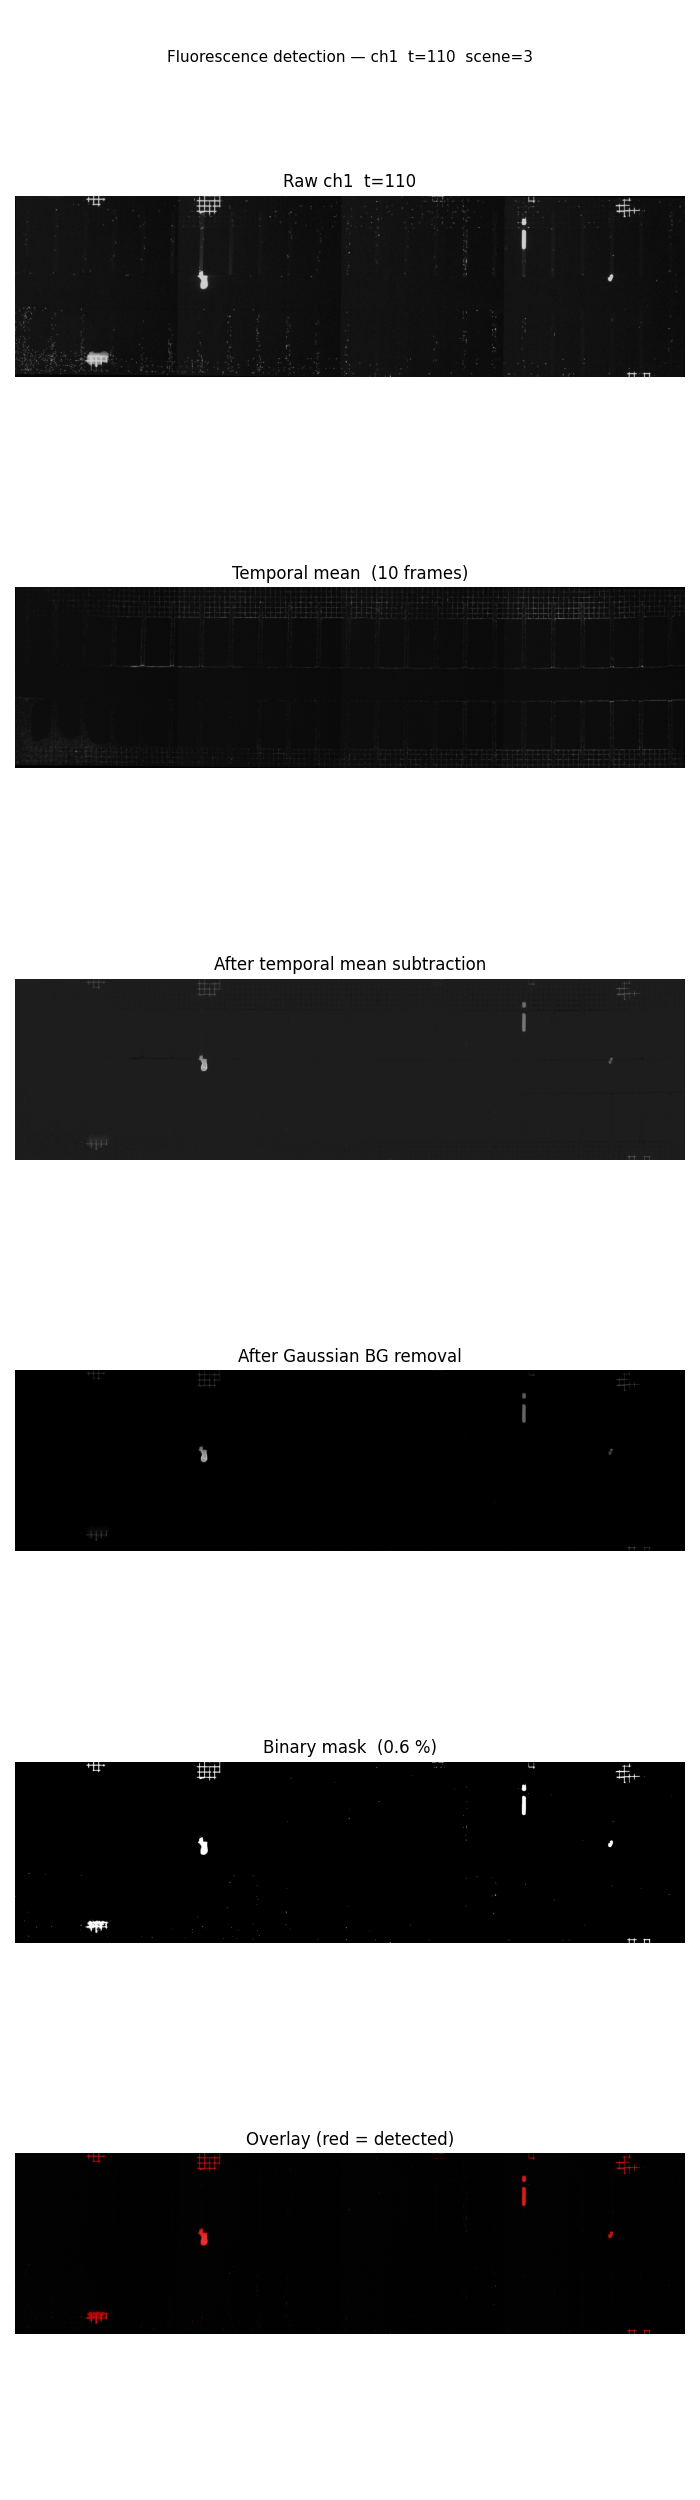

In [68]:
def detect_fluo_cells(img_raw, px_um,
                       temporal_mean=None,
                       bg_sigma_um=BG_SIGMA_UM,
                       min_obj_um2=MIN_OBJ_UM2,
                       max_hole_um2=MAX_HOLE_UM2,
                       thresh_factor=THRESH_FACTOR):
    """
    Detect fluorescent objects in a raw 2-D image.

    Steps:
      1. Normalise to [0, 1]
      2. Subtract temporal mean (pixel-wise, same scale) — removes static background
      3. Subtract Gaussian spatial background — removes residual gradients
      4. Otsu threshold  ×  thresh_factor
      5. Morphological clean-up

    Parameters
    ----------
    temporal_mean : np.ndarray or None
        Raw temporal mean image (same dtype/range as img_raw).
        If None, step 2 is skipped.

    Returns
    -------
    dict with keys: binary, bg_removed, img_tempsub, img_norm, otsu_thresh
    """
    img_norm = exposure.rescale_intensity(img_raw.astype(np.float32),
                                           out_range=(0.0, 1.0))

    # Step 1 — subtract temporal mean (normalised to same [0,1] scale)
    if temporal_mean is None:
        temporal_mean = 0

    img_tempsub = img_raw - temporal_mean
    img_tempsub = exposure.rescale_intensity(img_tempsub, out_range=(0.0, 1.0))
    # Step 2 — Gaussian spatial background removal
    sigma_px   = bg_sigma_um / px_um
    background = gaussian(img_tempsub, sigma=sigma_px, preserve_range=True)
    bg_rem     = np.clip(img_tempsub - background, 0, None)
    bg_rem     = exposure.rescale_intensity(bg_rem, out_range=(0.0, 1.0))
    # bg_rem     = img_tempsub

    # Step 3 — Otsu threshold
    otsu   = threshold_otsu(bg_rem)
    binary = bg_rem > thresh_factor * otsu

    # Step 4 — morphological clean-up
    min_px = max(1, int(np.round(min_obj_um2  / px_um ** 2)))
    max_px = max(1, int(np.round(max_hole_um2 / px_um ** 2)))
    binary = remove_small_objects(binary, min_size=min_px)
    binary = remove_small_holes(binary,   area_threshold=max_px)

    return dict(binary=binary, bg_removed=bg_rem,
                img_tempsub=img_tempsub, img_norm=img_norm,
                otsu_thresh=float(otsu))


# ── Run on reference frame ────────────────────────────────────────────────────
res_fluo = detect_fluo_cells(img_fluo, px_um, temporal_mean=temporal_mean_fluo)
coverage = res_fluo["binary"].mean()

print(f"  Otsu threshold  : {res_fluo['otsu_thresh']:.4f}  (×{THRESH_FACTOR})")
print(f"  Coverage        : {coverage*100:.2f} %")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(6, 1, figsize=(7, 25))
axes[0].imshow(img_fluo_disp,            cmap="gray");  axes[0].set_title(f"Raw ch{CHANNEL_FLUO}  t={TIMEPOINT}")
axes[1].imshow(temporal_mean_norm,        cmap="gray");  axes[1].set_title(f"Temporal mean  ({n_times} frames)")
axes[2].imshow(res_fluo["img_tempsub"],  cmap="gray");  axes[2].set_title("After temporal mean subtraction")
axes[3].imshow(res_fluo["bg_removed"],   cmap="gray");  axes[3].set_title("After Gaussian BG removal")
axes[4].imshow(res_fluo["binary"],       cmap="gray");  axes[4].set_title(f"Binary mask  ({coverage*100:.1f} %)")

overlay = np.stack([res_fluo["img_norm"]] * 3, axis=-1).copy()
m = res_fluo["binary"]
overlay[m, 0] = overlay[m, 0] * 0.3 + 0.7
overlay[m, 1] = overlay[m, 1] * 0.3
overlay[m, 2] = overlay[m, 2] * 0.3
axes[5].imshow(np.clip(overlay, 0, 1));                 axes[5].set_title("Overlay (red = detected)")

for ax in axes.flat: ax.axis("off")
plt.suptitle(f"Fluorescence detection — ch{CHANNEL_FLUO}  t={TIMEPOINT}  scene={SCENE}", fontsize=11)
plt.tight_layout()
plt.show()

## U-Net architecture + pillar inference (ML)

In [55]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=(32, 64, 128, 256)):
        super().__init__()
        self.pool      = nn.MaxPool2d(2, 2)
        self.downs     = nn.ModuleList()
        self.ups_trans = nn.ModuleList()
        self.ups_conv  = nn.ModuleList()
        ch = in_channels
        for feat in features:
            self.downs.append(DoubleConv(ch, feat)); ch = feat
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        for feat in reversed(features):
            self.ups_trans.append(nn.ConvTranspose2d(feat * 2, feat, 2, stride=2))
            self.ups_conv.append(DoubleConv(feat * 2, feat))
        self.final = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x)
        for i, (up_t, up_c) in enumerate(zip(self.ups_trans, self.ups_conv)):
            x = up_t(x); s = skips[-(i + 1)]
            if x.shape != s.shape: x = F.interpolate(x, size=s.shape[2:])
            x = torch.cat([s, x], dim=1); x = up_c(x)
        return self.final(x)


device = (torch.device("cuda")  if torch.cuda.is_available()
     else torch.device("mps")   if torch.backends.mps.is_available()
     else torch.device("cpu"))
print(f"Device: {device}")


def predict_unet(image, model_path, threshold=0.5,
                 patch_size=PATCH_SIZE_PX, patch_stride=PATCH_STRIDE_PX):
    img = image.astype(np.float64)
    lo, hi = img.min(), img.max()
    if hi - lo > 0: img = (img - lo) / (hi - lo)
    img = img.astype(np.float32)
    H_img, W_img = img.shape

    def _pad(n):
        if n <= patch_size: return patch_size - n
        r = (n - patch_size) % patch_stride
        return 0 if r == 0 else patch_stride - r

    img_pad = np.pad(img, ((0, _pad(H_img)), (0, _pad(W_img))), mode="reflect")
    H_pad, W_pad = img_pad.shape

    _model = UNet().to(device)
    _model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    _model.eval()

    prob_sum = np.zeros((H_pad, W_pad), np.float32)
    count    = np.zeros((H_pad, W_pad), np.float32)
    with torch.no_grad():
        for r in range(0, H_pad - patch_size + 1, patch_stride):
            for c in range(0, W_pad - patch_size + 1, patch_stride):
                patch = img_pad[r:r+patch_size, c:c+patch_size]
                t     = torch.from_numpy(patch[np.newaxis, np.newaxis]).to(device)
                prob  = torch.sigmoid(_model(t)).squeeze().cpu().numpy()
                prob_sum[r:r+patch_size, c:c+patch_size] += prob
                count   [r:r+patch_size, c:c+patch_size] += 1.0
    prob_map = (prob_sum / np.maximum(count, 1))[:H_img, :W_img]
    return dict(prob_map=prob_map, pred_binary=prob_map >= threshold,
                img_norm=img, coverage=float((prob_map >= threshold).mean()))

print("UNet + predict_unet() defined.")


# ── Run pillar detection ──────────────────────────────────────────────────────
print(f"Running pillar model on ch{CHANNEL_BF}  t={TIMEPOINT} …")
res_pillar = predict_unet(img_bf, PILLAR_MODEL_PATH, threshold=THRESHOLD_PILLAR)
print(f"  Done.  Pillar coverage = {res_pillar['coverage']*100:.2f} %")

Device: mps
UNet + predict_unet() defined.
Running pillar model on ch2  t=20 …
  Done.  Pillar coverage = 64.52 %


## Detected pillars — bounding boxes and grid alignment

/Users/bisot/Documents/PostDoc2/chipanalysis/chipanalysis/functions/pillar_detection.py:44: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(pred_binary.copy(), min_size=min_px)
/Users/bisot/Documents/PostDoc2/chipanalysis/chipanalysis/functions/pillar_detection.py:45: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous paramet

Detected 720 pillars


,id,centroid_col,centroid_row,width_px,height_px,width_um,height_um,area_um2,angle_deg,black_frac
0,1,2649.5,888.5,13.0,21.0,35.669939,57.620670,1938.631434,-90.0,0.055195
1,2,2547.5,888.0,14.0,23.0,38.413780,63.108353,2126.848078,-90.0,0.116667
2,3,2145.5,888.0,14.0,23.0,38.413780,63.108353,2168.255740,-90.0,0.102778
3,4,2083.0,888.0,14.0,98.0,38.413780,268.896460,9708.214502,-90.0,0.048485
4,5,2183.5,887.5,15.0,49.0,41.157621,134.448230,4490.849128,-90.0,0.165000
...,...,...,...,...,...,...,...,...,...,...
715,716,177.0,8.0,16.0,22.0,43.901463,60.364511,2586.096690,-90.0,0.025575
716,717,152.5,8.0,16.0,23.0,43.901463,63.108353,2537.160362,-90.0,0.083333
717,718,127.0,8.0,16.0,22.0,43.901463,60.364511,2499.517034,-90.0,0.053708
718,719,102.0,8.0,16.0,22.0,43.901463,60.364511,2465.638038,-90.0,0.066496


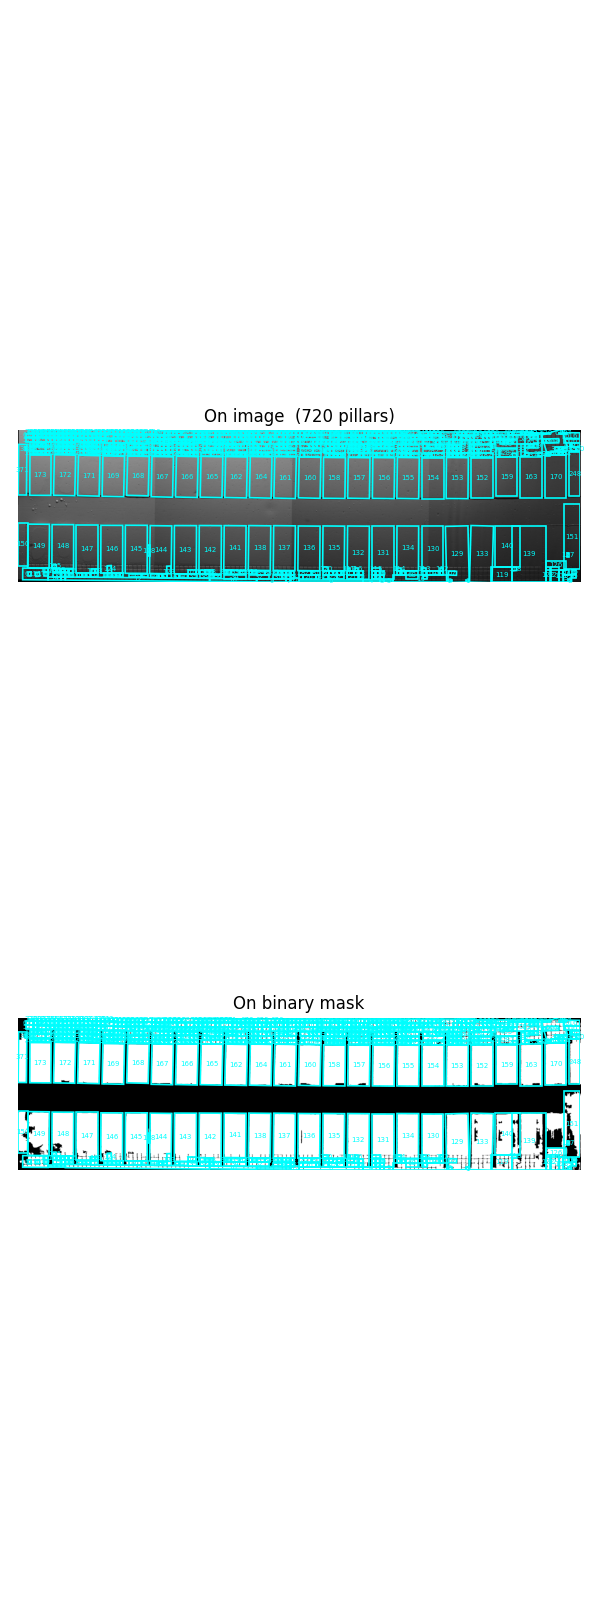

In [58]:
from importlib import reload
import chipanalysis.functions.pillar_detection as pd_mod
reload(pd_mod)
from chipanalysis.functions.pillar_detection import (
    clean_pillar_mask, detect_pillars, pillars_to_dataframe,
    estimate_grid_rotation, rotate_and_redetect, draw_pillar_boxes,
)

MIN_PILLAR_UM2 = 1000.0
MAX_BLACK_FRAC = 0.35

pillar_clean = clean_pillar_mask(res_pillar["pred_binary"], px_um, MIN_PILLAR_UM2)
pillar_list  = detect_pillars(pillar_clean, px_um, MAX_BLACK_FRAC, MIN_PILLAR_UM2)
df_pillars   = pillars_to_dataframe(pillar_list)
print(f"Detected {len(pillar_list)} pillars")
display(df_pillars)

fig, axes = plt.subplots(2, 1, figsize=(6, 16))
axes[0].imshow(res_pillar["img_norm"], cmap="gray", vmin=0, vmax=1)
axes[1].imshow(pillar_clean, cmap="gray", vmin=0, vmax=1)
for ax in axes:
    draw_pillar_boxes(ax, pillar_list, color="cyan", fontsize=5)
    ax.axis("off")
axes[0].set_title(f"On image  ({len(pillar_list)} pillars)")
axes[1].set_title("On binary mask")
plt.tight_layout()
plt.show()

Band top     : row 404  (1108.5 µm)
Band bottom  : row 554  (1520.1 µm)
Band width   : 411.6 µm


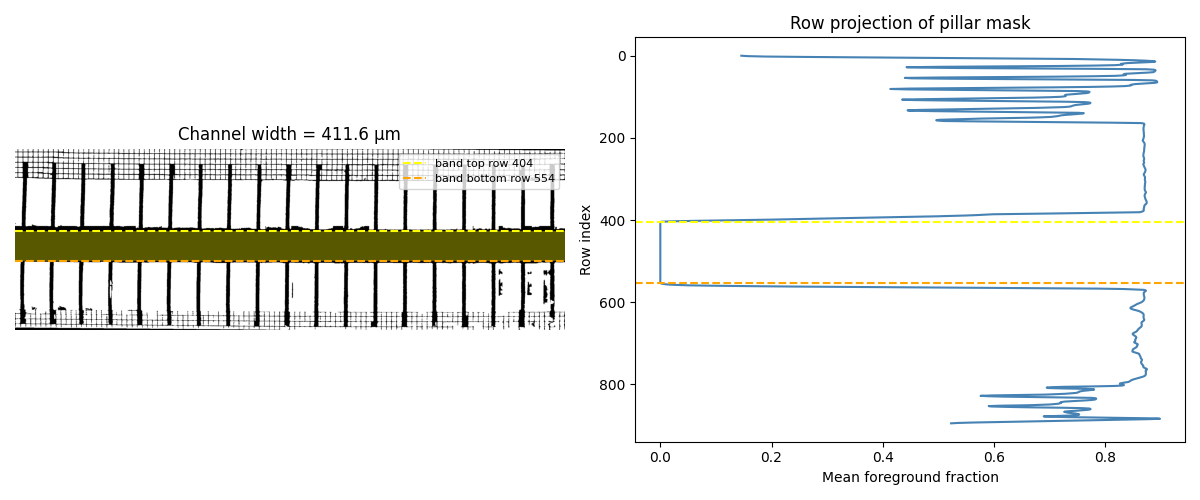

In [60]:
# ── Find channel from pillar_clean mask (row projection) ─────────────────────
pillar_clean = pillar_clean[:,150:-150]
row_fill = pillar_clean.mean(axis=1)          # mean foreground per row

# Smooth slightly to avoid noise
from scipy.ndimage import uniform_filter1d
row_smooth = uniform_filter1d(row_fill.astype(np.float32), size=5)

# Split image in half — top pillars are above midline, bottom below
mid = row_smooth.size // 2
top_rows    = row_smooth[:mid]
bottom_rows = row_smooth[mid:]

# band_top = last row (from top) where top pillars are still filled
band_top    = int(np.where(top_rows > 0)[0].max())
# band_bottom = first row (from top) where bottom pillars start
band_bottom = int(np.where(bottom_rows > 0)[0].min()) + mid

band_centre_row    = (band_top + band_bottom) / 2.0
band_half_width_um = (band_bottom - band_top) / 2.0 * px_um

print(f"Band top     : row {band_top}  ({band_top*px_um:.1f} µm)")
print(f"Band bottom  : row {band_bottom}  ({band_bottom*px_um:.1f} µm)")
print(f"Band width   : {(band_bottom - band_top)*px_um:.1f} µm")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(pillar_clean, cmap="gray")
W = pillar_clean.shape[1]
axes[0].add_patch(plt.Rectangle((0, band_top), W, band_bottom - band_top,
                                 linewidth=0, facecolor="yellow", alpha=0.35))
axes[0].axhline(band_top,    color="yellow", lw=1.5, ls="--", label=f"band top row {band_top}")
axes[0].axhline(band_bottom, color="orange", lw=1.5, ls="--", label=f"band bottom row {band_bottom}")
axes[0].legend(fontsize=8); axes[0].axis("off")
axes[0].set_title(f"Channel width = {(band_bottom-band_top)*px_um:.1f} µm")

axes[1].plot(row_smooth, np.arange(len(row_smooth)), color="steelblue")
axes[1].axhline(band_top,    color="yellow", lw=1.5, ls="--")
axes[1].axhline(band_bottom, color="orange", lw=1.5, ls="--")
axes[1].invert_yaxis()
axes[1].set_xlabel("Mean foreground fraction"); axes[1].set_ylabel("Row index")
axes[1].set_title("Row projection of pillar mask")

plt.tight_layout(); plt.show()

## Horizontal band detection (k-means on pillar rows)

## Re-run fluorescence detection at a different timepoint → df_cells

The pillar band geometry is **fixed** from above.
Set `TIMEPOINT_CELLS` to any T index to analyse a different frame.

In [61]:
timepoints = [10,20,30,50,60,70,80,90,100,110]   # ← change this independently of the pillar timepoint
# timepoints = [20]   # ← change this independently of the pillar timepoint

records = []
for TIMEPOINT_CELLS in timepoints:
    # ── Load and detect ───────────────────────────────────────────────────────────
    img_fluo_t, _ = get_frame(czi, TIMEPOINT_CELLS, CHANNEL_FLUO, scene=SCENE,
                                gamma=1.0, stretch_min=1, stretch_max=99.5)
    img_fluo_t = result['rotate_fn'](img_fluo_t)
    res_fluo_t = detect_fluo_cells(img_fluo_t, px_um, temporal_mean=temporal_mean_fluo)
    print(f"Coverage at t={TIMEPOINT_CELLS}: {res_fluo_t['binary'].mean()*100:.2f} %")

    # ── Label individual objects ──────────────────────────────────────────────────
    cell_bin = res_fluo_t["binary"].copy()
    H_bf, W_bf = res_pillar["img_norm"].shape
    if cell_bin.shape != (H_bf, W_bf):
        cell_bin = sk_resize(cell_bin.astype(np.float32), (H_bf, W_bf),
                            order=0, preserve_range=True,
                            anti_aliasing=False).astype(bool)

    cell_bin     = remove_small_objects(cell_bin, min_size=max(1, int(MIN_OBJ_UM2 / px_um**2)))
    cell_labeled = sk_label(cell_bin)
    cell_regions = sk_regionprops(cell_labeled)

    # ── Build df_cells ────────────────────────────────────────────────────────────
    for reg in cell_regions:
        cy, cx  = reg.centroid
        dist_px = cy - band_centre_row
        records.append({
            "id":              reg.label,
            "centroid_row":    cy,
            "centroid_col":    cx,
            "dist_to_band_px": dist_px,
            "dist_to_band_um": dist_px * px_um,
            "area_px":         reg.area,
            "area_um2":        reg.area * px_um ** 2,
            "time" : TIMEPOINT_CELLS
        })

df_cells = pd.DataFrame(records)
print(f"Detected {len(df_cells)} objects  (t={TIMEPOINT_CELLS})")
display(df_cells.head(10))

/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_89169/3888287605.py:50: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=min_px)
/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_89169/3888287605.py:51: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.

Coverage at t=10: 3.99 %


/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_89169/3888287605.py:50: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=min_px)
/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_89169/3888287605.py:51: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.

Coverage at t=20: 4.36 %


/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_89169/3888287605.py:50: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=min_px)
/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_89169/3888287605.py:51: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.

...

Coverage at t=90: 0.79 %


/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_89169/3888287605.py:50: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=min_px)
/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_89169/3888287605.py:51: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.

Coverage at t=100: 0.64 %
Coverage at t=110: 0.56 %
Detected 20260 objects  (t=110)


/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_89169/3888287605.py:50: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=min_px)
/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_89169/3888287605.py:51: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.

,id,centroid_row,centroid_col,dist_to_band_px,dist_to_band_um,area_px,area_um2,time
0,1,1.500000,439.500000,-477.500000,-1310.184280,18.0,135.515984,10
1,2,0.000000,514.500000,-479.000000,-1314.300042,4.0,30.114663,10
2,3,0.166667,607.666667,-478.833333,-1313.842736,6.0,45.171995,10
3,4,0.285714,664.142857,-478.714286,-1313.516088,7.0,52.700660,10
4,5,0.615385,693.461538,-478.384615,-1312.611525,13.0,97.872655,10
5,6,0.807692,709.000000,-478.192308,-1312.083863,26.0,195.745310,10
6,7,0.850000,760.300000,-478.150000,-1311.967777,20.0,150.573315,10
7,8,1.092308,783.276923,-477.907692,-1311.302923,65.0,489.363275,10
8,9,1.066667,829.133333,-477.933333,-1311.373278,15.0,112.929986,10
9,10,1.729730,852.972973,-477.270270,-1309.553938,37.0,278.560633,10


## Visualise — cell positions relative to band

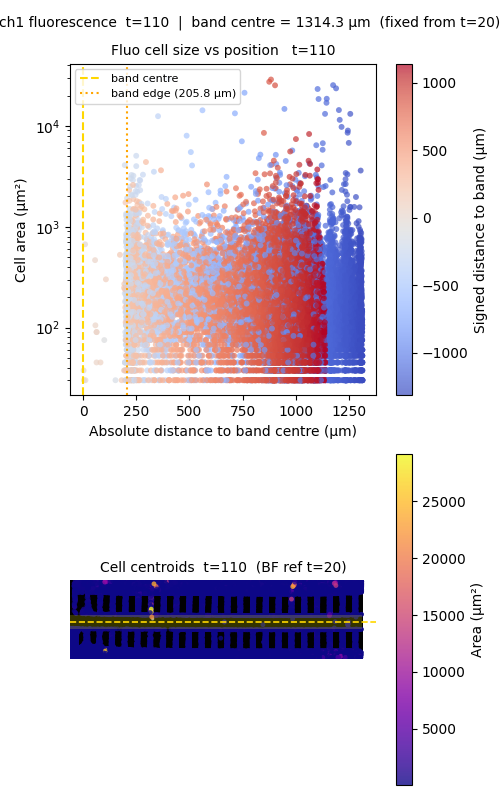

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(5, 8))

# Left — scatter: distance vs area
sc = axes[0].scatter(
    np.abs(df_cells["dist_to_band_um"]), df_cells["area_um2"],
    c=df_cells["dist_to_band_um"], cmap="coolwarm",
    s=18, alpha=0.7, linewidths=0,
)
plt.colorbar(sc, ax=axes[0], label="Signed distance to band (µm)")
axes[0].axvline(0, color="gold", lw=1.5, ls="--", label="band centre")
axes[0].axvline(band_half_width_um, color="orange", lw=1.5, ls=":",
                label=f"band edge ({band_half_width_um:.1f} µm)")
axes[0].set_xlabel("Absolute distance to band centre (µm)")
axes[0].set_ylabel("Cell area (µm²)")
axes[0].set_title(f"Fluo cell size vs position   t={TIMEPOINT_CELLS}", fontsize=10)
axes[0].legend(fontsize=8)
axes[0].set_yscale("log")


# Right — spatial map overlaid on fluorescence image
axes[1].imshow(img_fluo_t, cmap="gray")
sc2 = axes[1].scatter(
    df_cells["centroid_col"], df_cells["centroid_row"],
    c=df_cells["area_um2"], cmap="plasma",
    s=12, alpha=0.8, linewidths=0,
)
plt.colorbar(sc2, ax=axes[1], label="Area (µm²)")
W_ = res_pillar["img_norm"].shape[1]
axes[1].add_patch(plt.Rectangle((0, band_top), W_, band_bottom - band_top,
                                  linewidth=0, facecolor="yellow", alpha=0.2))
axes[1].axhline(band_centre_row, color="gold", lw=1.2, ls="--")
axes[1].set_title(f"Cell centroids  t={TIMEPOINT_CELLS}  (BF ref t={TIMEPOINT})", fontsize=10)
axes[1].axis("off")

plt.suptitle(
    f"ch{CHANNEL_FLUO} fluorescence  t={TIMEPOINT_CELLS}  |  "
    f"band centre = {band_centre_row*px_um:.1f} µm  (fixed from t={TIMEPOINT})",
    fontsize=10,
)
plt.tight_layout()
plt.show()

Found 9 objects inside band with area < 1000 µm²
Total objects in band region: 161

Small objects statistics:
  Area range: 30.1 — 105.4 µm²
  Distance range: -99.6 — 81.9 µm


,id,centroid_row,centroid_col,dist_to_band_px,dist_to_band_um,area_px,area_um2,time
1989,1990,442.700000,2530.200000,-36.300000,-99.601444,10.0,75.286658,10
1990,1991,502.000000,3155.166667,23.000000,63.108353,6.0,45.171995,10
5367,1992,475.000000,3012.500000,-4.000000,-10.975366,4.0,30.114663,20
5368,1993,501.833333,3155.916667,22.833333,62.651046,12.0,90.343989,20
8820,2006,500.071429,3155.428571,21.071429,57.816659,14.0,105.401321,30
11775,1535,477.500000,1756.500000,-1.500000,-4.115762,4.0,30.114663,50
11776,1536,502.333333,3156.250000,23.333333,64.022967,12.0,90.343989,50
14433,1341,478.200000,1755.400000,-0.800000,-2.195073,5.0,37.643329,60
16718,937,508.833333,2192.833333,29.833333,81.857936,6.0,45.171995,70


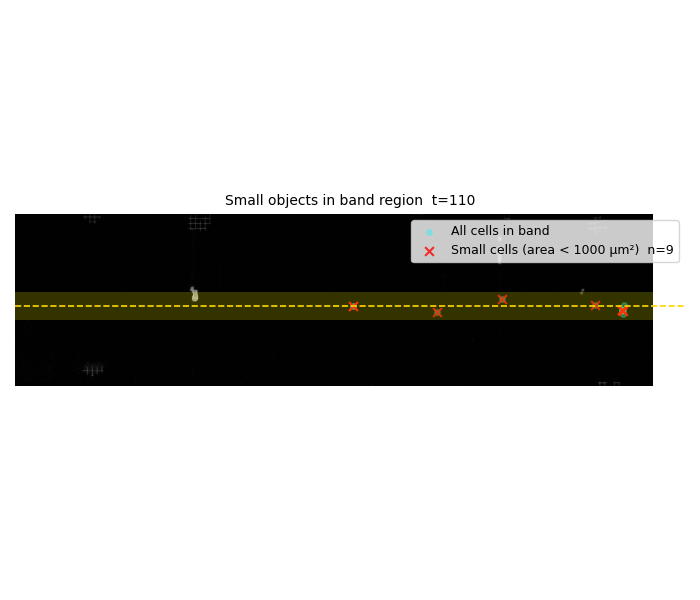

In [69]:

# ── Filter for small objects inside the band region ───────────────────────────
# "Inside band" = absolute distance to band centre ≤ band_half_width_um
small_in_band = df_cells[
    (np.abs(df_cells["dist_to_band_um"]) < 0.6*band_half_width_um) &
    (df_cells["area_um2"] < 200)
]

print(f"Found {len(small_in_band)} objects inside band with area < 1000 µm²")
print(f"Total objects in band region: {len(df_cells[np.abs(df_cells['dist_to_band_um']) <= band_half_width_um])}")
print(f"\nSmall objects statistics:")
print(f"  Area range: {small_in_band['area_um2'].min():.1f} — {small_in_band['area_um2'].max():.1f} µm²")
print(f"  Distance range: {small_in_band['dist_to_band_um'].min():.1f} — {small_in_band['dist_to_band_um'].max():.1f} µm")

display(small_in_band)

# ── Visualise them on the image ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(img_fluo_t, cmap="gray")

# All cells in band (semitransparent)
all_in_band = df_cells[np.abs(df_cells["dist_to_band_um"]) <= 0.6*band_half_width_um]
ax.scatter(
    all_in_band["centroid_col"], all_in_band["centroid_row"],
    s=15, alpha=0.3, color="cyan", label="All cells in band"
)

# Small cells (highlighted)
ax.scatter(
    small_in_band["centroid_col"], small_in_band["centroid_row"],
    s=40, alpha=0.8, color="red", marker="x", linewidths=1.5,
    label=f"Small cells (area < 1000 µm²)  n={len(small_in_band)}"
)

W_ = res_pillar["img_norm"].shape[1]
ax.add_patch(plt.Rectangle((0, band_top), W_, band_bottom - band_top,
                              linewidth=0, facecolor="yellow", alpha=0.2))
ax.axhline(band_centre_row, color="gold", lw=1.2, ls="--")
ax.legend(fontsize=9, loc="upper right")
ax.set_title(f"Small objects in band region  t={TIMEPOINT_CELLS}", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()
